In [169]:
#%%
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from scipy.linalg import expm
from scipy.integrate import simpson
import jclsquant as jcl
from tqdm import tqdm

In [ ]:
### Constants of the model

# BASIC
hbar = jcl.hbar_fs 

# PHYSICAL
hw = 1.0
omega_l = hw / hbar
T = 2*np.pi/omega_l
gamma = 0.025
# RABI
omega1 = np.sqrt(3)*2.7*gamma*np.pi/hbar
omega0 = omega_l
# VALLEY SELECTION IN EFFECTIVE MODEL
nu = -1
# MODEL SELECTION
model = 'effective'
pol = np.pi/2
# Energy adjustments
broad = 0.05
dE = broad / 1.5

# Time evolution adjustments
N_periods = 50
steps_per_T = 1000
meas_per_T = 100
t_vec = np.linspace(0, N_periods*T, steps_per_T*N_periods)
n_vec_measures = np.linspace(0, len(t_vec)-1, meas_per_T*N_periods, dtype=int)
N_measures = meas_per_T*N_periods
t_vec_measures = t_vec[n_vec_measures]

dt = t_vec[1]
# K-space adjustments
km = 0.0
alpha = np.pi

a_l = 0.24595
hvf = a_l*2.7*np.sqrt(3)/2
if model=='effective':
    evfA0 = gamma*np.pi*2.7*np.sqrt(3)/2
    def Ham(km, alpha, t):
        Ham = np.zeros((2, 2), dtype=np.complex128)
        Ham[0, 1] = nu*hvf*km*np.exp(1j*nu*alpha) + hbar*omega1*(nu*np.cos(omega_l*t) - 1j*np.cos(omega_l*t + pol))/2
        Ham[0, 0] = hbar*omega0/2
        #Ham[0, 1] = hvf*km*np.exp(1j*nu*alpha) + hbar*omega1*np.exp(-1j*omega_l*t)/2
        Ham[1, 0] = np.conj(Ham[0, 1])
        Ham[1, 1] = -hbar*omega0/2
        return Ham

if model=='real':
    a1 = a_l*np.array([np.sqrt(3)/2, 0.5])
    a2 = a_l*np.array([np.sqrt(3)/2, -0.5])
    d1 = a_l*np.array([1/np.sqrt(3), 0])
    d2 = d1 - a1
    d3 = d1 - a2
    def Ham(km, alpha, t):
        k_vec = km*np.array([np.cos(alpha), np.sin(alpha)]) + np.pi*gamma/a_l*np.array([np.cos(omega_l*t), np.cos(omega_l*t + pol)])
        Ham = np.zeros((2, 2), dtype=np.complex128)
        Ham[0, 1] = -2.7*(np.exp(1j*np.vdot(k_vec, d1)) + np.exp(1j*np.vdot(k_vec, d2)) + np.exp(1j*np.vdot(k_vec, d3)))
        Ham[1, 0] = np.conj(Ham[0, 1])
        return Ham

In [ ]:
# Calculating first eigenvalues and selecting the starting state accordingly
autV, autE = np.linalg.eigh(Ham(0, 0, 0))
EF_list = np.arange(autV[0] - 20*dE, autV[1] + 20*dE, dE)

# Initialization and definition of variables
rho0 = np.outer(np.conj(autE[:,0]), autE[:,0])



al_list = np.linspace(0, 2*np.pi, 1)
km = np.abs(autV[0])/hvf

DOS_list = np.zeros((len(al_list), len(n_vec_measures), len(EF_list)))
N_list = np.zeros((len(al_list), len(n_vec_measures), len(EF_list)))

for a in range(len(al_list)):
    meas_count = 0
    rho = np.copy(rho0)
    for i in range(len(t_vec)):
        U  = expm(-1j*Ham(km, alpha, t_vec[i])*dt/hbar)
        if i == n_vec_measures[meas_count]:
            # Calculation of wanted results
            delta_op = np.linalg.inv((EF_list[:,None,None]*np.eye(2)- Ham(km, alpha, t_vec[i]))@(EF_list[:,None,None]*np.eye(2) - Ham(km, alpha, t_vec[i])) + np.eye(2)*broad**2)
            DOS_list[a, meas_count] = broad/np.pi*np.trace(delta_op, axis1=1, axis2=2)
            N_list[a, meas_count] = broad/np.pi*np.trace(delta_op@rho, axis1=1, axis2=2)
            meas_count += 1
        
        # Time evolution of relevant variables
        rho = U@rho@np.conj(U.T)



In [203]:
#DOS_list_int = simpson(DOS_list, al_list, axis=0)
#N_list_int = simpson(N_list, al_list, axis=0)
DOS_list_int = DOS_list[0]
N_list_int = N_list[0]

Text(0.5, 1.0, 'Density of States')

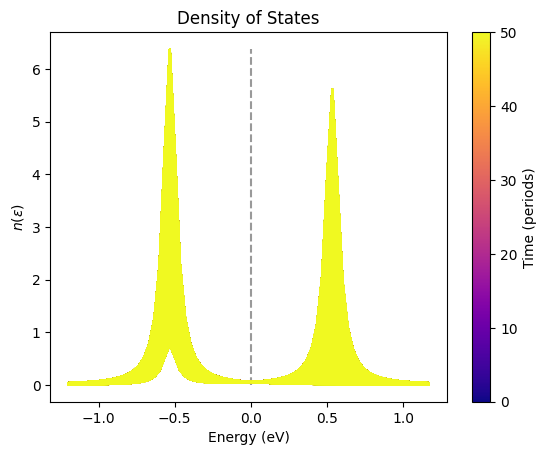

In [204]:
cmap = plt.cm.plasma 
norm = Normalize(vmin=t_vec[0]/T, vmax=t_vec[-1]/T)

# DOS (Energy)
fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list, N_list_int[i,:], color=cmap(norm(t_vec_measures[i])), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
#ax.vlines(hw_hlines, 0, np.max(dos_list), color='grey', ls='--', alpha=0.5, zorder=1)
ax.vlines([0], 0, np.max(DOS_list), color='grey', ls='--', alpha=0.8, zorder=1)
ax.set_title('Density of States')

(0.0, 10.0)

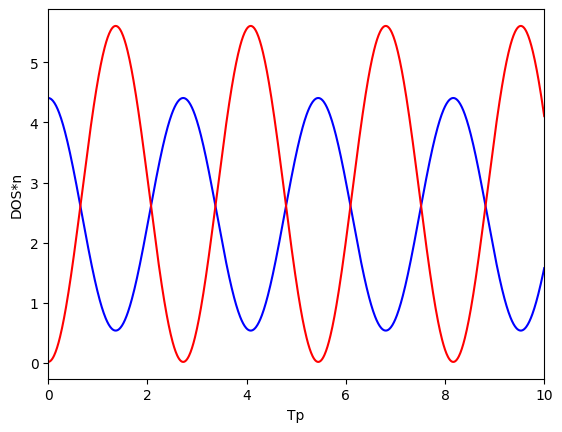

In [205]:
fig, ax = plt.subplots()
ax.plot(t_vec_measures/T, N_list_int[ :,19], c='blue')
ax.plot(t_vec_measures/T, N_list_int[:,-20], c='red')
ax.set_xlabel('Tp')
ax.set_ylabel('DOS*n')
ax.set_xlim(0, 10)

(0.0, 10.0)

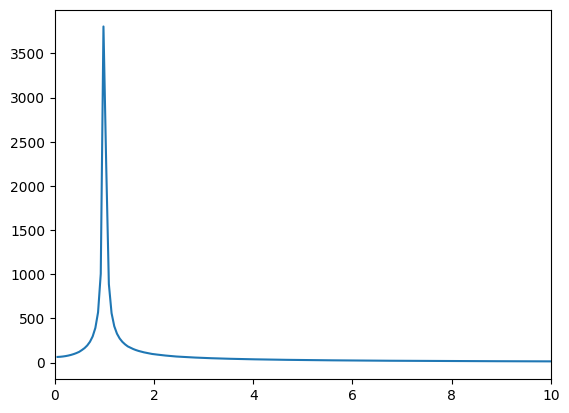

In [206]:
# Fourier Stuff
amp = np.abs(np.fft.rfft(N_list_int[:,19])[1:])
freqs = np.fft.rfftfreq(N_measures, t_vec_measures[1])[1:]*2*np.pi

fig, ax = plt.subplots()
ax.plot(freqs/omega1, amp)
ax.set_xlim(0, 10)